In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [2]:
COLUMNS = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty_level'
]

In [3]:
df = pd.read_csv("data/KDDTrain+.txt", names=COLUMNS)

# Convert to binary classification
df['binary_class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (125973, 44)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level,binary_class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [4]:
X = df.drop(['class','binary_class','difficulty_level'], axis=1)
y = df['binary_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (100778, 41)
Test shape: (25195, 41)


In [5]:
preprocessor = joblib.load("models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)

Processed train shape: (100778, 121)


In [6]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)
# --- Checking stability of feature importance across different random seeds ---
print("Checking stability of feature importance across different random seeds...")

rf_alt = RandomForestClassifier(random_state=0)
rf_alt.fit(X_train_processed, y_train)

importance_difference = np.abs(
    rf.feature_importances_ - rf_alt.feature_importances_
)

print("Average importance difference between runs:",
      importance_difference.mean())

Checking stability of feature importance across different random seeds...
Average importance difference between runs: 0.002617662863200394


In [7]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(10)

,feature,importance
2,num__dst_bytes,0.139586
1,num__src_bytes,0.116439
119,cat__flag_SF,0.066402
29,num__dst_host_srv_count,0.059725
26,num__diff_srv_rate,0.055968
25,num__same_srv_rate,0.041918
31,num__dst_host_diff_srv_rate,0.039592
30,num__dst_host_same_srv_rate,0.034392
22,num__srv_serror_rate,0.031850
115,cat__flag_S0,0.030221


In [8]:
# --- Importance Summary Statistics ---
print("Maximum Importance:", importance_df['importance'].max())
print("Minimum Importance:", importance_df['importance'].min())
print("Number of near-zero importance features:",
      (importance_df['importance'] < 0.001).sum())

Maximum Importance: 0.13958604312847386
Minimum Importance: 0.0
Number of near-zero importance features: 80


In [9]:
importance_df['feature'] = importance_df['feature'].str.replace('num__', '', regex=False)
importance_df['feature'] = importance_df['feature'].str.replace('cat__', '', regex=False)

In [10]:

importance_df['feature'] = (
    importance_df['feature']
    .str.replace('num__','', regex=False)
    .str.replace('cat__','', regex=False)
)

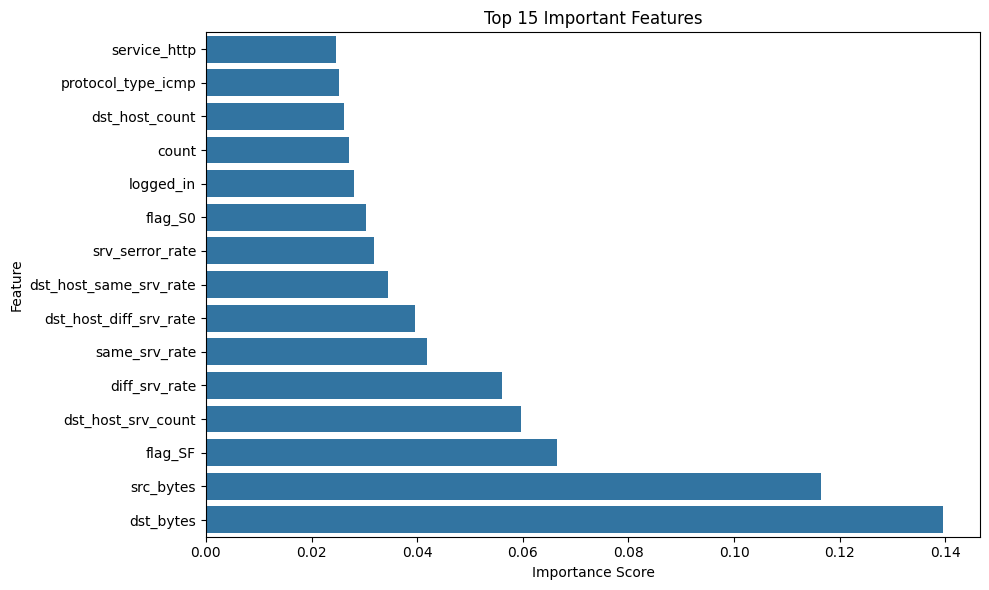

In [11]:
top_features = importance_df.head(15).sort_values(by='importance')

plt.figure(figsize=(10,6))
sns.barplot(
    x='importance',
    y='feature',
    data=top_features
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

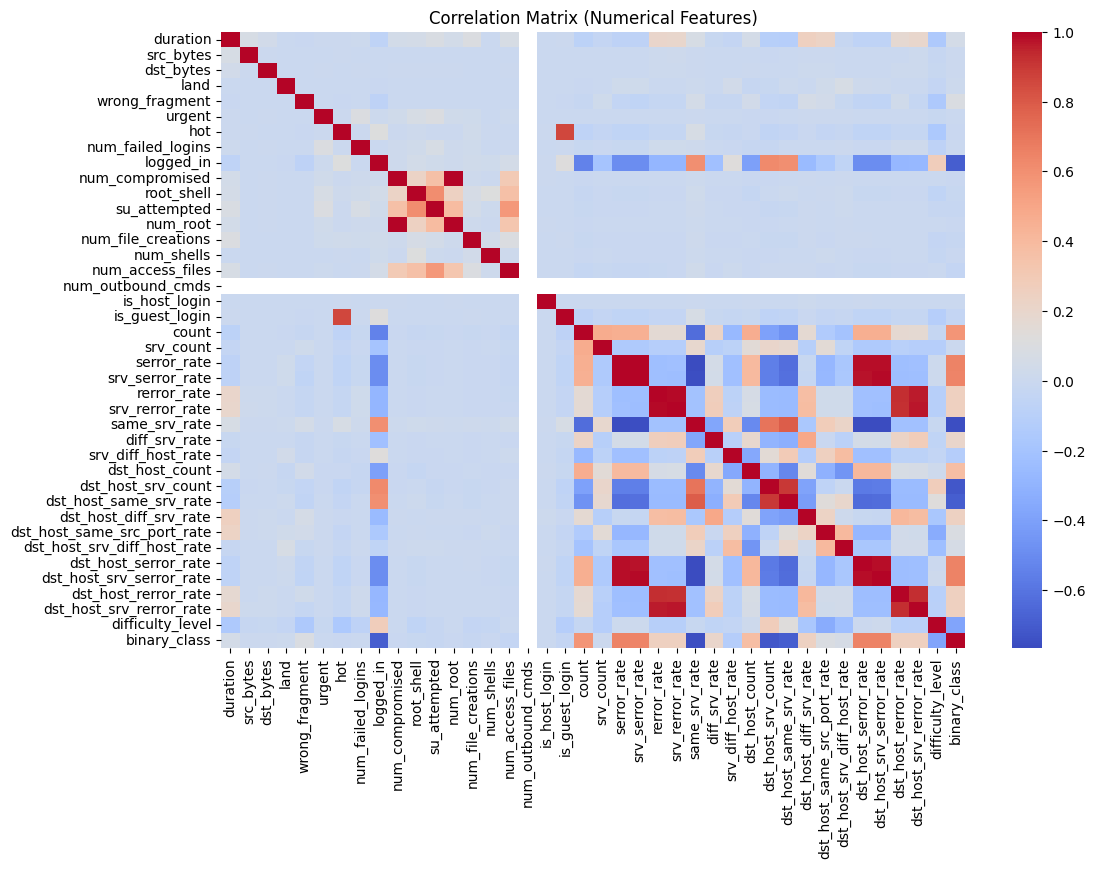

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix (Numerical Features)")
plt.show()

In [13]:
top_n = 20

selected_features = importance_df.head(top_n)['feature']

mask = importance_df['feature'].isin(selected_features)
selected_indices = np.where(mask)[0]

threshold = 0.01

selected_threshold = importance_df[
    importance_df['importance'] > threshold
]['feature']

print("Features selected using threshold:", len(selected_threshold))


X_train_selected = X_train_processed[:, selected_indices]
X_test_selected = X_test_processed[:, selected_indices]

print("Original feature count:", X_train_processed.shape[1])
print("Reduced feature count:", X_train_selected.shape[1])

Features selected using threshold: 25
Original feature count: 121
Reduced feature count: 20


In [14]:
model_full = LogisticRegression(max_iter=500)
model_full.fit(X_train_processed, y_train)

y_pred_full = model_full.predict(X_test_processed)

print("Performance with All Features")
print(classification_report(y_test, y_pred_full))

Performance with All Features
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



In [15]:
model_selected = LogisticRegression(max_iter=500)
model_selected.fit(X_train_selected, y_train)

y_pred_selected = model_selected.predict(X_test_selected)

print("Performance with Selected Features")
print(classification_report(y_test, y_pred_selected))

Performance with Selected Features
              precision    recall  f1-score   support

           0       0.87      0.79      0.83     13469
           1       0.78      0.86      0.82     11726

    accuracy                           0.82     25195
   macro avg       0.82      0.82      0.82     25195
weighted avg       0.83      0.82      0.82     25195



In [16]:
from sklearn.metrics import recall_score, precision_score

print("Recall (All Features):",
      recall_score(y_test, y_pred_full))

print("Recall (Selected Features):",
      recall_score(y_test, y_pred_selected))

Recall (All Features): 0.9629029507078287
Recall (Selected Features): 0.858775370970493


In [17]:
acc_full = accuracy_score(y_test, y_pred_full)
acc_selected = accuracy_score(y_test, y_pred_selected)

print("Accuracy (All Features):", acc_full)
print("Accuracy (Selected Features):", acc_selected)

Accuracy (All Features): 0.9718991863464973
Accuracy (Selected Features): 0.8218297281206589


In [ ]:
from sklearn.feature_selection import RFE

# Use Logistic Regression as base estimator
base_model = LogisticRegression(max_iter=500)

rfe = RFE(estimator=base_model, n_features_to_select=20)

X_train_rfe = rfe.fit_transform(X_train_processed, y_train)
X_test_rfe = rfe.transform(X_test_processed)

print("Selected features using RFE:", X_train_rfe.shape)

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train_processed)
X_test_var = selector.transform(X_test_processed)

print("After Variance Threshold:", X_train_var.shape)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("PCA reduced shape:", X_train_pca.shape)

In [ ]:
top_feature = importance_df.iloc[0]['feature']

sns.histplot(
    data=df,
    x=top_feature.split('__')[-1],
    hue='binary_class',
    bins=50
)
plt.title(f"Distribution of {top_feature}")
plt.show()

In [ ]:
# --- Distribution of Most Important Feature ---
most_important_feature = importance_df.iloc[0]['feature']

plt.figure(figsize=(8,4))
sns.boxplot(
    x=df['binary_class'],
    y=df[most_important_feature]
)

plt.title(f"{most_important_feature} Distribution by Class")
plt.show()